# Examen práctico — Q-Learning tabular con Pac-Man

En este ejercicio trabajaremos con una versión pequeña de Pac-Man diseñada para poder resolverse completamente mediante **Q-Learning tabular**.

La lógica es la misma usada previamente:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

y:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma \max_{a'}Q(S_{t+1},a')
-
Q(S_t,A_t)
\right].
$$

## Objetivo

Implementar un agente Q-Learning capaz de aprender una política que permita a Pac-Man:

- comer tantas comidas como sea posible;
- evitar al fantasma;
- reducir movimientos innecesarios.

> La implementación del ambiente y la visualización ya están disponibles.  
> La tarea consiste en implementar **el agente y su proceso de aprendizaje**.


## 1. Importaciones y ambiente


In [1]:
import sys
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

PROJECT_ROOT = Path.cwd()
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tabular_pacman_env import (
    TabularPacmanEnv,
    ACTIONS,
)

env = TabularPacmanEnv(seed=7)

print("Número de estados:", env.n_states)
print("Número de acciones:", env.n_actions)


Número de estados: 1944
Número de acciones: 4


## 2. El estado de Pac-Man

Para mantener una Q-table de tamaño manejable utilizaremos la representación:

$$
s=(p,g,n)
$$

donde:

- $p$: posición de Pac-Man;
- $g$: posición del fantasma;
- $n$: número de comidas que permanecen en el tablero.

El ambiente mantiene internamente la posición exacta de cada comida para poder simular y visualizar el juego. Sin embargo, **esa configuración completa no forma parte del estado que recibe la Q-table**.

Por tanto:

$$
n_{\text{states}}
=
n_p\,n_g\,(N_{\text{food}}+1).
$$

Esta es una **representación simplificada del estado**: dos configuraciones distintas de comida pueden compartir el mismo $(p,g,n)$.


Estado codificado: 47
Estado decodificado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)


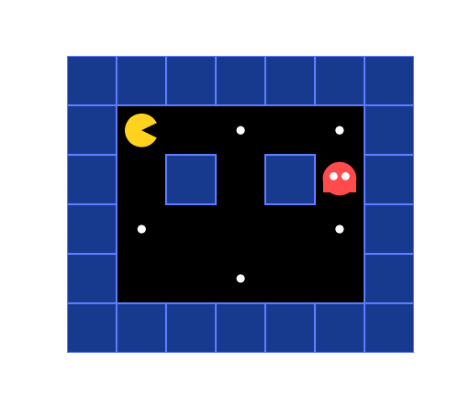

In [2]:
state = env.reset(seed=7)

print("Estado codificado:", state)
print("Estado decodificado:", env.decode_state(state))

frame = env.render()

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.show()


### Pregunta 1

Dos tableros pueden tener:

- la misma posición de Pac-Man;
- la misma posición del fantasma;
- el mismo número de comidas restantes;

pero las comidas pueden estar ubicadas en lugares diferentes.

¿Representaría nuestra Q-table ambos tableros como el mismo estado o como estados diferentes? Explique.

**Como el mismo estado, ya que el estado se codifica como la pocision del Pac Man, del fantasma y el numero de comidas restantes, no se incluye las casillas especificas en donde esta la comida.**
**Generar un estado distinto para ambos casos daria lo mismo porque los parametros no cambian, ambos comparten la misma fila de la Q-table**

## 3. Acciones


In [3]:
print(ACTIONS)
print("Acciones legales desde el estado inicial:")
print([ACTIONS[a] for a in env.get_legal_actions()])


{0: 'up', 1: 'right', 2: 'down', 3: 'left'}
Acciones legales desde el estado inicial:
['right', 'down']


Las acciones disponibles son:

| Código | Acción |
|---:|---|
| 0 | arriba |
| 1 | derecha |
| 2 | abajo |
| 3 | izquierda |

El ambiente evita atravesar paredes.


## 4. Observar una transición


In [4]:
state = env.reset(seed=7)

action = env.get_legal_actions()[0]

next_state, reward, done, info = env.step(action)

print("S_t       =", state)
print("A_t       =", ACTIONS[action])
print("R_(t+1)   =", reward)
print("S_(t+1)   =", next_state)
print("done      =", done)
print()
print("S_(t+1) decodificado:")
print(env.decode_state(next_state))


S_t       = 47
A_t       = right
R_(t+1)   = -1
S_(t+1)   = 185
done      = False

S_(t+1) decodificado:
PacmanState(pacman=(1, 2), ghost=(3, 5), food_remaining=5)


La transición observada tiene la forma:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

### Pregunta 2

¿Cuáles de los siguientes valores son entregados directamente por el ambiente y cuáles debe aprender/estimar el agente?

- $R_{t+1}$: **Lo entrega directamente el ambiente como recompensa (env.step())**
- $S_{t+1}$: **Lo entrega directamente el ambiente como un nuevo estado (env.step())**
- $Q(S_t,A_t)$: **Debe ser aprendido o estimado por el agente mediante la Q-table**
- $\max_{a'}Q(S_{t+1},a')$: **Debe calcularlo el agente usando los valores aprendidos en la Q-table**


## 5. Q-table


Construya una Q-table inicializada en cero.

Debe tener dimensiones:

$$
n_{\text{states}}\times n_{\text{actions}}.
$$


In [5]:
# TODO 1 — Inicializar la Q-table
#
# Recibe / ya está disponible:
#   - env.n_states : número total de estados discretos del ambiente.
#   - env.n_actions: número total de acciones posibles.
#
# Debe implementar:
#   - Una matriz NumPy Q con una fila por estado y una columna por acción.
#   - Todos los valores deben iniciar en 0.
#
# Resultado esperado:
#   Q.shape == (env.n_states, env.n_actions)
#
# TODO: escriba aquí su solución.

Q = np.zeros((env.n_states, env.n_actions))

Q

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], shape=(1944, 4))

In [6]:
# Esta celda debe ejecutarse cuando TODO 1 esté correcto.

print("Shape esperado:", (env.n_states, env.n_actions))
print("Shape obtenido :", Q.shape)

assert Q.shape == (env.n_states, env.n_actions)
assert np.all(Q == 0)

print("✓ Q-table creada correctamente")


Shape esperado: (1944, 4)
Shape obtenido : (1944, 4)
✓ Q-table creada correctamente


## 6. Política ε-greedy


Implemente:

$$
A_t=
\begin{cases}
\text{acción aleatoria}, & \text{con probabilidad }\epsilon\\[4pt]
\arg\max_a Q(S_t,a), & \text{con probabilidad }1-\epsilon
\end{cases}
$$

Use únicamente las **acciones legales** del estado actual.

Si varias acciones tienen el mismo máximo Q-value, seleccione aleatoriamente entre ellas.


In [7]:
# ============================================================
# TODO 2 — Política epsilon-greedy
# ============================================================
#
# Complete la función choose_action().
#
# Recibe:
#   Q       : tabla Q de tamaño (n_states, n_actions).
#   state   : estado actual del agente, representado por un entero.
#   epsilon : probabilidad de exploración.
#   env     : ambiente de Pac-Man.
#
# El ambiente proporciona:
#
#   env.get_legal_actions()
#
# que retorna una lista con las acciones válidas desde la
# posición actual de Pac-Man.
#
# Implemente una política epsilon-greedy:
#
#   - Con probabilidad epsilon:
#       seleccione ALEATORIAMENTE una de las acciones legales.
#
#   - Con probabilidad 1 - epsilon:
#       seleccione, entre las acciones legales, aquella con
#       mayor valor Q para el estado actual.
#
# Importante:
#   No se deben seleccionar acciones que no sean legales.
#
# Retorna:
#   action : entero correspondiente a la acción seleccionada.
#
# ============================================================

def choose_action(Q, state, epsilon, env):
    legal_actions = env.get_legal_actions()

    # Probabilidad epsilon
    if random.random() < epsilon:
            return random.choice(legal_actions)

    # Probabilidad 1 - epsilon
    values = [Q[state, action] for action in legal_actions]
    max_value = max(values)

    best_actions = [
        action
        for action, value in zip(legal_actions, values)
        if value == max_value
    ]

    return random.choice(best_actions)

### Pregunta 3

Si $\epsilon=0.10$:

1. ¿cuál es la probabilidad de explorar?

**0.1 (10%), se elige aleatoriamente una accion legal**

2. ¿cuál es la probabilidad de explotar?

**0.90 (90%), se selecciona la accion legal con mayor valor Q**

3. ¿qué ocurre cuando todos los Q-values iniciales son iguales?

**Ninguna accion es mejor que otra, entonces se selecciona aleatoriamente entre las acciones legales, hasta que las actualizaciones de Q-Learning empiecen a diferencial los valores.**

## 7. Actualización Q-Learning


Para cada transición utilice:

$$
\text{TD target}
=
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
$$

$$
\text{TD error}
=
\text{TD target}
-
Q(S_t,A_t)
$$

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)+\alpha(\text{TD error})
$$

Cuando $S_{t+1}$ sea terminal:

$$
\max_{a'}Q(S_{t+1},a')=0.
$$


In [8]:
# ============================================================
# TODO 3
# Implemente una actualización de Q-Learning.
# Debe retornar td_target y td_error.
# ============================================================

def update_q(
    Q,
    state,
    action,
    reward,
    next_state,
    done,
    alpha,
    gamma,
):
    # TODO
    if done:
        td_target = reward
    else:
        td_target = reward + gamma * np.max(Q[next_state])

    td_error = td_target - Q[state, action]
    Q[state, action] += alpha * td_error

    return td_target, td_error


### Prueba manual de la actualización


In [9]:
# Esta celda NO entrena al agente.
# Solo permite revisar una actualización controlada.

Q_test = np.zeros((env.n_states, env.n_actions))

s = env.reset(seed=7)
a = env.get_legal_actions()[0]

s_next, r, done, _ = env.step(a)

# Valor ficticio conocido para verificar el cálculo.
if not done:
    Q_test[s_next, 1] = 4.0

td_target, td_error = update_q(
    Q_test,
    state=s,
    action=a,
    reward=r,
    next_state=s_next,
    done=done,
    alpha=0.5,
    gamma=0.9,
)

print("TD target:", td_target)
print("TD error :", td_error)
print("Nuevo Q  :", Q_test[s, a])


TD target: 2.6
TD error : 2.6
Nuevo Q  : 1.3


### Pregunta 4

Explique con sus palabras la diferencia entre:

- **TD target: valor objetivo estimado para la accion actual, combina la recompensa inmediata con el valor estimado del mejor futuro, representa cuanto deberia valer aproximadamente Q(s, a)** 
- **TD error: diferencia entre el objetivo y el valor Q actual, si es positivo la accion resulto mejor de lo esperado, si es negativo, peor, muestra cuanto debe corregirse la estimacion**
- **nuevo Q-value: valor actuaalizado mediante la tasa de aprendizaje, es un paso pequeño hacia el objetivo para que el aprendizaje sea estable**


## 8. Entrenamiento


Implemente el ciclo completo de entrenamiento:

1. reiniciar el ambiente;
2. seleccionar una acción con $\epsilon$-greedy;
3. ejecutar la acción;
4. observar $R_{t+1}$ y $S_{t+1}$;
5. actualizar $Q(S_t,A_t)$;
6. avanzar al nuevo estado;
7. terminar cuando `done=True`.

Guarde la recompensa total obtenida en cada episodio.


In [10]:
# TODO 4 — Entrenamiento
#
# Recibe:
#   - env       : ambiente de Pac-Man.
#   - Q         : Q-table que será actualizada.
#   - episodes  : número de episodios de entrenamiento.
#   - alpha     : tasa de aprendizaje.
#   - gamma     : factor de descuento.
#   - epsilon   : valor inicial de exploración.
#   - epsilon_min   : mínimo valor permitido de epsilon.
#   - epsilon_decay : factor de decaimiento de epsilon.
#
# En cada episodio debe:
#   1. Reiniciar el ambiente y obtener state.
#   2. Elegir action usando epsilon_greedy.
#   3. Ejecutar:
#          next_state, reward, done, info = env.step(action)
#   4. Actualizar Q usando q_learning_update.
#   5. Reemplazar state por next_state.
#   6. Acumular la recompensa del episodio.
#   7. Continuar hasta done=True o alcanzar max_steps.
#   8. Reducir epsilon sin bajar de epsilon_min.
#
# Retorna:
#   - rewards_history: recompensa total de cada episodio.
#   - epsilon_history: epsilon utilizado a lo largo del entrenamiento.
#
def train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
    epsilon_min=0.01,
    epsilon_decay=0.995,
):
    Q = np.zeros((env.n_states, env.n_actions))

    episode_rewards = []
    episode_lengths = []
    wins = []

    for episode in range(episodes):

        state = env.reset(seed=seed + episode)

        total_reward = 0
        steps = 0

        for _ in range(max_steps):

            # 1. Seleccionar acción
            action = choose_action(Q, state, epsilon, env)

            # 2. Interactuar con el ambiente
            next_state, reward, done, info = env.step(action)

            # 3. Actualizar Q
            update_q(Q, state, action, reward, next_state, done, alpha, gamma)

            # 4. Actualizar estado y métricas
            state = next_state
            total_reward += reward
            steps += 1

            if done:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
        wins.append(int(info.get("won", False)))

        # Reducir epsilon sin bajar de epsilon_min.
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, episode_rewards, episode_lengths, wins


## 9. Entrenar


In [11]:
Q, rewards, lengths, wins = train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
    epsilon_min=0.01,
    epsilon_decay=0.995,
)

print("Entrenamiento terminado")
print("Q-table:", Q.shape)


Entrenamiento terminado
Q-table: (1944, 4)


## 10. Curva de aprendizaje


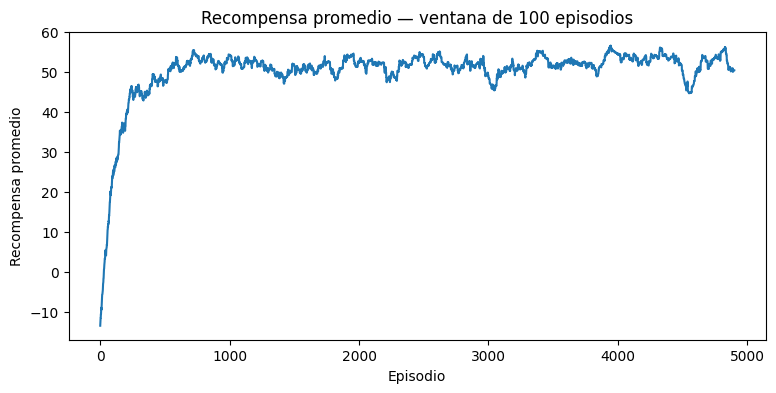

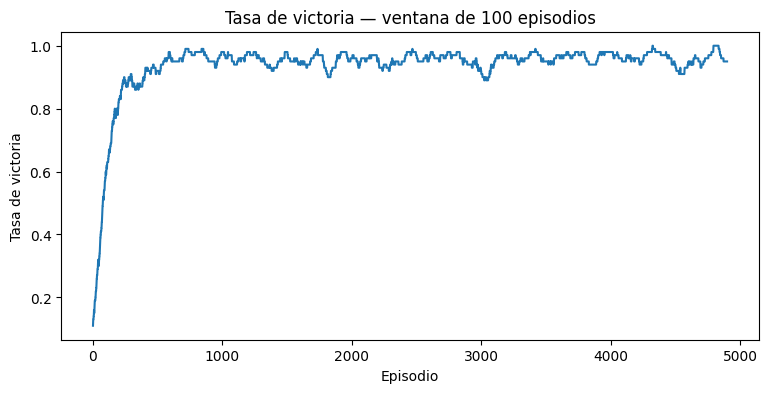

In [12]:
window = 100

moving_reward = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid",
)

moving_win_rate = np.convolve(
    wins,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(9, 4))
plt.plot(moving_reward)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Recompensa promedio — ventana de {window} episodios")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(moving_win_rate)
plt.xlabel("Episodio")
plt.ylabel("Tasa de victoria")
plt.title(f"Tasa de victoria — ventana de {window} episodios")
plt.show()


### Pregunta 5

A partir de las curvas:

1. ¿hay evidencia de aprendizaje?: 

**Si, la recompensa promedio y la tasa de victoria mejoran a medida que pasan los episodios en vez de mantenerse iguales que en los episodios del principio.**

2. ¿qué ocurre con la recompensa promedio?

**Al inicio, la recompensa promedio es negativa (-10), porque el agente no ha aprendido una politica efectiva, con el entrenamiento, la recompensa promedio mejora y se estabiliza en valores alrededor de 40-60 en la parte final.Esto muestra que el agente aprendio a comer mas y a evitar fantasmas en menos pasos**

3. ¿qué ocurre con la tasa de victoria?

 **La tasa de victoria empieza baja (0.15) y aumenta gradualmente hasta 0.95 o más, esto indica que el agente gana cada vez mas y que la politica aprendida es efectiva, logra cumplir mejor el objetivo del juego.**

## 11. Política aprendida


In [13]:
state = env.reset(seed=7)
decoded = env.decode_state(state)

print("Estado:", decoded)
print()

legal_actions = env.get_legal_actions()

for action in legal_actions:
    print(
        f"{ACTIONS[action]:>8} : "
        f"Q = {Q[state, action]:.3f}"
    )

best_value = max(Q[state, a] for a in legal_actions)

best_actions = [
    a for a in legal_actions
    if Q[state, a] == best_value
]

print()
print("Mejor(es) acción(es):", [ACTIONS[a] for a in best_actions])


Estado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)

   right : Q = 5.937
    down : Q = 31.719

Mejor(es) acción(es): ['down']


### Pregunta 6

Interprete los Q-values del estado inicial.

¿Qué acción prefiere el agente y qué significa que una acción tenga un Q-value mayor que otra?

**El agente prefiere la accion "down", porque tiene el mayor Q-value entre las acciones legales del estado inicial.**

**Un Q-value mayor indica que el agente estima una recompensa acumulada futura mas alta al ejecutar esa accion, considerando las recompensas inmediatas y las consecuencias posteriores. Por eso, el agente prefiere esa accion**

## 12. Reproducir un episodio


In [14]:
def greedy_action(Q, state, env):
    legal_actions = env.get_legal_actions()

    values = np.array([
        Q[state, action]
        for action in legal_actions
    ])

    best_value = np.max(values)

    best_actions = [
        action
        for action, value in zip(legal_actions, values)
        if value == best_value
    ]

    return random.choice(best_actions)


def play_episode(
    env,
    Q=None,
    random_policy=False,
    seed=20,
    max_steps=100,
):
    state = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for step in range(max_steps):

        if random_policy:
            action = random.choice(env.get_legal_actions())
        else:
            action = greedy_action(Q, state, env)

        next_state, reward, done, info = env.step(action)

        total_reward += reward
        state = next_state
        frames.append(env.render())

        if done:
            break

    return frames, total_reward, step + 1, info


def frames_to_video(frames, interval=300):
    fig = plt.figure(figsize=(7, 5))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True,
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


### Política aleatoria


In [15]:
frames_random, reward_random, steps_random, info_random = play_episode(
    env,
    random_policy=True,
    seed=20,
)

print("Reward:", reward_random)
print("Pasos :", steps_random)
print("Comió :", info_random["food_eaten"], "de", env.max_food)
print("Ganó  :", info_random["won"])

frames_to_video(frames_random)


Reward: -33
Pasos : 26
Comió : 2 de 5
Ganó  : False


### Política aprendida


In [16]:
frames_trained, reward_trained, steps_trained, info_trained = play_episode(
    env,
    Q=Q,
    random_policy=False,
    seed=20,
)

print("Reward:", reward_trained)
print("Pasos :", steps_trained)
print("Comió :", info_trained["food_eaten"], "de", env.max_food)
print("Ganó  :", info_trained["won"])

frames_to_video(frames_trained)


Reward: 59
Pasos : 16
Comió : 5 de 5
Ganó  : True


### Pregunta 7

Compare el episodio aleatorio con el episodio del agente entrenado.

Discuta:

- cantidad de movimientos;
- recompensa total;
- cantidad de comidas recolectadas;
- comportamiento frente al fantasma.

Explique por qué la recompensa acumulada favorece simultáneamente **comer**, **usar menos pasos** y **evitar morir**.


- **Política aleatoria: realizo 26 movimientos, obtuvo una recompensa total de -33 y recolecto 2 de 5 comidas. No gano y termino en la misma posicion que el fantasma, lo que indica que fue alcanzado.**
- **Agente entrenado: realizo 16 movimientos, obtuvo una recompensa de 59 y recolecto 5 de 5 comidas. Gano el episodio y evito al fantasma.**

**La recompensa acumulada favorece estos comportamientos porque comer comidas proporciona recompensas positivas, mientras que cada movimiento innecesario genera un costo. Ademas, morir o ser alcanzado por el fantasma produce una penalización grande. El agente aprende a recolectar todas las comidas usando pocos pasos y evitando situaciones peligrosas.**

## 13. Evaluación final


In [17]:
def evaluate_policy(
    env,
    Q,
    episodes=200,
    max_steps=100,
):
    rewards = []
    lengths = []
    wins = []

    for episode in range(episodes):

        state = env.reset(seed=10000 + episode)
        total_reward = 0

        for step in range(max_steps):

            action = greedy_action(Q, state, env)

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)
        wins.append(int(info.get("won", False)))

    return {
        "reward_promedio": np.mean(rewards),
        "pasos_promedio": np.mean(lengths),
        "tasa_victoria": np.mean(wins),
    }


results = evaluate_policy(env, Q)
results


{'reward_promedio': np.float64(52.785),
 'pasos_promedio': np.float64(21.13),
 'tasa_victoria': np.float64(0.965)}

## Entrega

El notebook debe ejecutar completamente y contener:

1. Q-table correctamente inicializada;
2. política $\epsilon$-greedy;
3. actualización de Q-Learning;
4. ciclo de entrenamiento;
5. curva de aprendizaje;
6. interpretación de resultados;
7. comparación entre política aleatoria y política aprendida.

No se requiere modificar el código del ambiente.
